plot_PCA notebook
- Generates PCA visualizations of compositional search space in two dimensions, allowing analysis of compositional variation in FALCON generated LNPs 
- Ensure the <u>R kernel (falcon-env)</u> is selected.
- Run configuration and PCA computation before main executable 
- Note: This script requires composition datasets of LNP formulations

In [ ]:
### Required Run Parameters ### 

#Name of the csv file, used to extract composition data
# DATASET_NAME = 'Normalized_RAMOS_Single_Objective_3ITER_DSPC_DlinMC3CMA'  # fig 2 composition dataset 
# DATASET_NAME = 'SuppFig1_PCA_Acquisition_Stability'  # SI Fig 1 PCA dataset
DATASET_NAME = 'Normalized_RAMOS_C2C12_DC24_3T3_Quad_Objective_3ITER_18PG_SM102'  # SI Fig 13 composition dataset

RUN_NAME = "0530_RAMOS" #for saving generated plots
# cell_type = 'RAMOS' # only needed if you want to shade by LnRLU
cell_type = 'Selectivity' 

### Configuration ###

In [90]:
library(ggplot2)

In [91]:
# Updated custom theme
custom_theme <- theme(
  plot.background = element_rect(fill = "transparent", colour = NA),  # Plot background
  panel.background = element_rect(fill = "transparent", colour = NA),  # Main panel
  plot.title = element_text(size = 35, hjust = 0.5, face = "plain", colour = "black"), 
  axis.text.y = element_text(size = 30, face = "plain", colour = "black"),  
  axis.text.x = element_text(size = 30, face = "plain", colour = "black"), 
  axis.title.x = element_text(size = 35, face = "plain", colour = "black"),  
  axis.title.y = element_text(size = 35, face = "plain", colour = "black"), 
  axis.line.x.bottom = element_line(color = "black", size = 1),  # Thicker black x-axis line
  axis.line.y.left = element_line(color = "black", size = 1),    # Thicker black y-axis line
  axis.ticks.length = unit(0.4, "cm"),  # Bigger tick marks
  axis.ticks = element_line(color = "black", size = 1.5),  # Thicker black tick marks
  legend.background = element_blank(),
  legend.key = element_blank(),
  panel.grid.major = element_blank(),
  panel.grid.minor = element_blank(),
  legend.text = element_text(size = 22),  
  legend.title = element_text(size = 22),  
  legend.key.size = unit(3, "lines")
)

In [92]:
#check if RUN_NAME exists, if not create it
output_path <- file.path("..", "/output/", RUN_NAME)
if (!dir.exists(output_path)) {
  dir.create(output_path)
}

### PCA Computation ###

In [93]:
# import data 
data <- read.csv(paste0("../datasets/", DATASET_NAME, ".csv"))
head(data)

ï..Formula_label,Iter,Opt_Method,Cell_Target,Ionizable_Lipid,Helper_lipid,NP_ratio,HL_IL.HL,IL.HL,PEG_PEG.Chol,SM.102_PcntMolar,X18PG_PcntMolar,Cholesterol_PcntMolar,DMG.PEG2000_PcntMolar,LnRLU_RAMOS,LnRLU_DC,LnRLU_3T3,LnRLU_C2C12,LnRLU_Selectivity
1,0,Grid-Search,N/A,SM-102,18PG,10,80,50,5,40,40,19.0,1.0,3.297588,6.872449,2.588296,6.267701,-1.945228
2,0,Grid-Search,N/A,SM-102,18PG,7,80,50,5,40,40,19.0,1.0,3.521809,6.832332,2.961373,6.530907,-1.919729
3,0,Grid-Search,N/A,SM-102,18PG,4,80,50,5,40,40,19.0,1.0,3.332920,6.506941,3.847793,5.637323,-1.997766
4,0,Grid-Search,N/A,SM-102,18PG,10,80,50,1,40,40,19.8,0.2,3.522874,8.347627,4.451180,8.257223,-3.495803
5,0,Grid-Search,N/A,SM-102,18PG,7,80,50,1,40,40,19.8,0.2,3.349231,8.309963,3.236933,8.802801,-3.434002
6,0,Grid-Search,N/A,SM-102,18PG,4,80,50,1,40,40,19.8,0.2,3.365292,5.482794,4.904895,3.681076,-1.324296


In [94]:
# Run PCA on the dataset, keeping only the first two principal components
selected_cols <- c("NP_ratio", "HL_IL.HL", "IL.HL", "PEG_PEG.Chol")

pca <- prcomp(data[, selected_cols], center = TRUE, scale. = TRUE)
summary(pca) # Summarizes importance of the principal components

# Extract the principal components
pca_data <- data.frame(pca$x)

# Combine with the species data for plotting
pca_data$Iter <- data$Iter
pca_data$Opt_Method <- data$Opt_Method
RLU_col <- paste0("LnRLU_", cell_type)
pca_data$RLU <- data[[RLU_col]]
pca_data$Cell_Target <- data$Cell_Target
pca_data$Formula_label <- data$Formula_label

Importance of components:
                          PC1    PC2    PC3    PC4
Standard deviation     1.1544 1.0192 0.9508 0.8512
Proportion of Variance 0.3332 0.2597 0.2260 0.1812
Cumulative Proportion  0.3332 0.5929 0.8188 1.0000

### Plotting ###

##### Fig 2 Plots (Examples) #####

Saving 6.67 x 6.67 in image


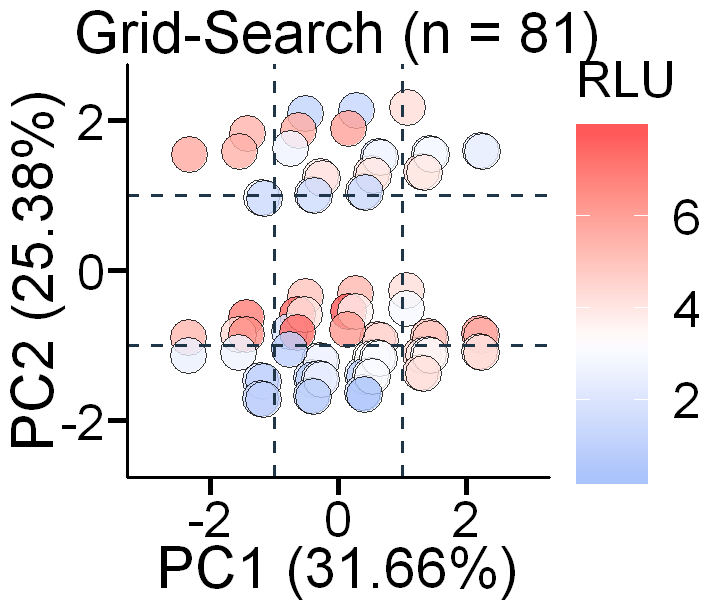

In [ ]:
#Plot Grid

# Generate the plot
hist_data <- subset(pca_data, Iter == 0)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#72a5f8", mid = "#ffffff", high = "#ff5959", midpoint = median(hist_data$RLU)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Grid-Search (n = 81)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 30), # Increase the size of the legend title
        )
# Display the plot

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter1_PCA.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


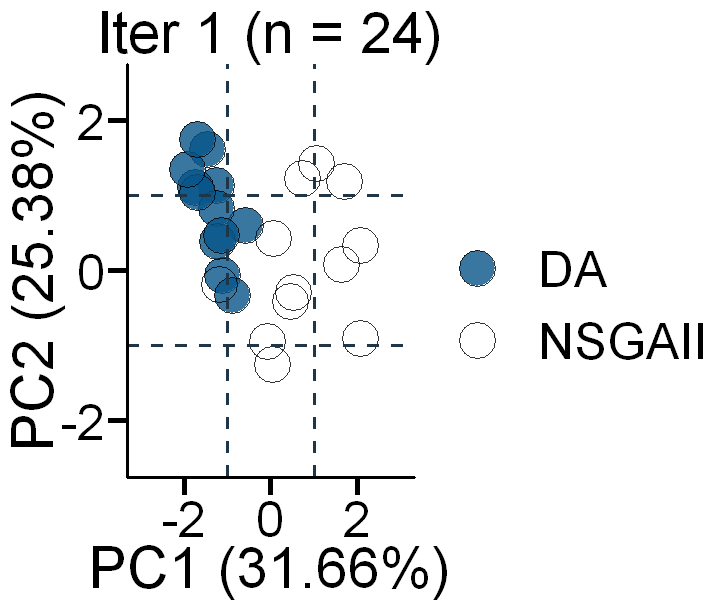

In [112]:
#Plot Iter1

# Generate the plot
custom_colors <- c("DA" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 1)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 1 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Changed from 'color' to 'fill'
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, cell_type, "Fig2_Iter1_PCA.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


In [ ]:
#Plot Iter2

# Generate the plot
custom_colors <- c("DA" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 2)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 2 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Change legend title to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, cell_type, "Fig2_Iter2_PCA.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


In [ ]:
#Plot Iter3

# Generate the plot
custom_colors <- c("DA" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 3)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 3 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Update to match fill aesthetic
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, cell_type, "Fig2_Iter3_PCA.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Saving 6.67 x 6.67 in image


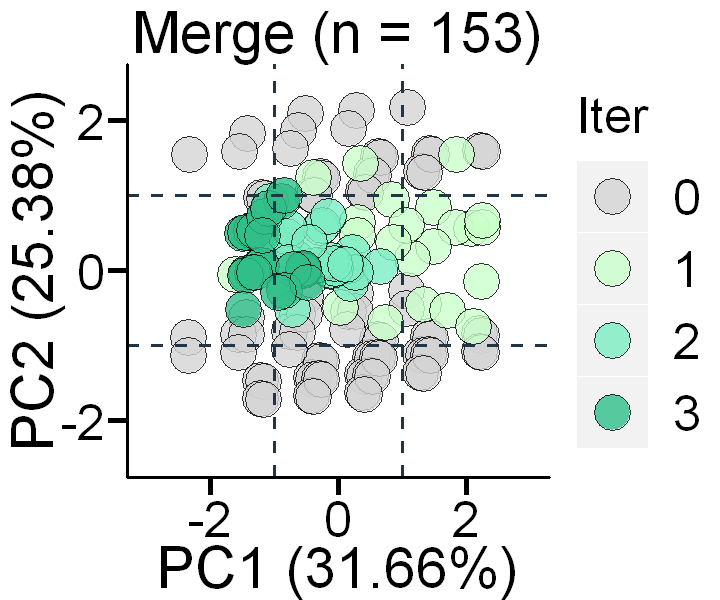

In [ ]:
#Plot Merge
custom_colors <- c("0" = "#d4d4d4", "1" = "#caffca", "2" = "#7bedc3", "3" = "#30bf89")

p_pca <- ggplot(pca_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Merge (n = 153)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, cell_type, "Fig2_Merge_PCA.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


##### SI Fig 1 Plots (Examples) #####

Saving 6.67 x 6.67 in image


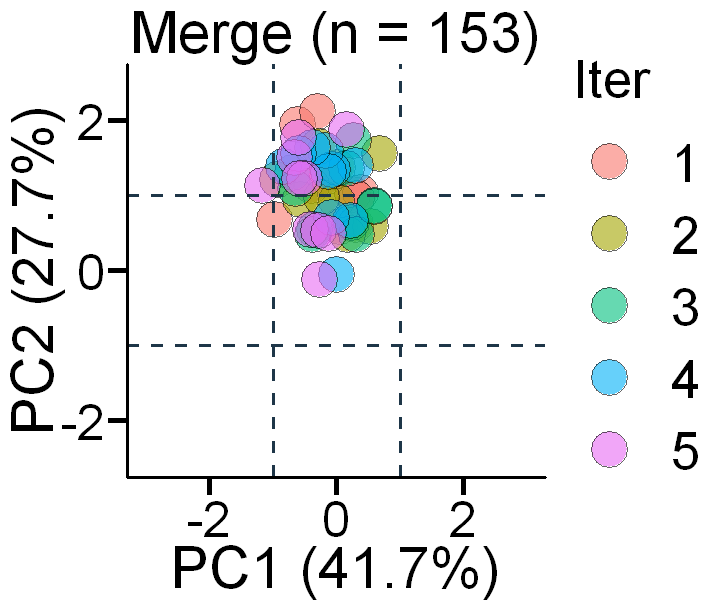

In [ ]:
#Plot Merge for RAMOS

#exclude iter 0
hist_data <- subset(pca_data, Cell_Target == "RAMOS")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.6, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  #scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Merge (n = 153)",
       x = "PC1 (41.7%)",
       y = "PC2 (27.7%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 32),
    legend.title = element_text(size = 32)
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig1_RAMOS_Acquisition.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Saving 6.67 x 6.67 in image


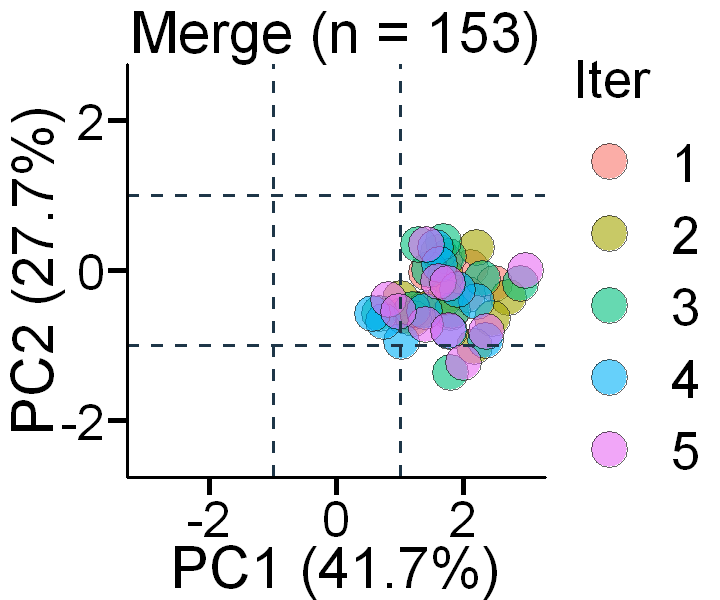

In [ ]:
#Plot Merge for THP

#exclude iter 0
hist_data <- subset(pca_data, Cell_Target == "THP1")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.6, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  #scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Merge (n = 153)",
       x = "PC1 (41.7%)",
       y = "PC2 (27.7%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 32),
    legend.title = element_text(size = 32)
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig1_THP1_Acquisition.png")
#ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


##### SI Fig 13 Plot (Example) #####

Warning message:
"Removed 5 rows containing missing values (geom_point)."Warning message:
"Removed 5 rows containing missing values (geom_point)."

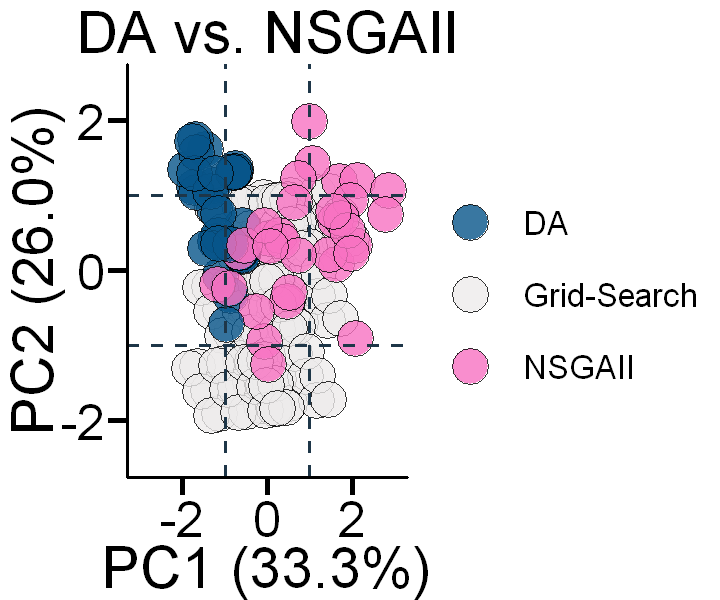

In [ ]:
#Plot the DA vs. NSGA-II

# Generate the plot
custom_colors <- c("Grid-Search" = "#edebeb","DA" = "#07558a", "NSGAII" = "#f872c2")
hist_data <- subset(pca_data)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "DA vs. NSGAII",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)",
       fill = "") +  # Update to match fill aesthetic
  theme(
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 20),
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_AlgoComp.png")
#ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)


Warning message:
"Removed 2 rows containing missing values (geom_point)."Warning message:
"Removed 2 rows containing missing values (geom_point)."

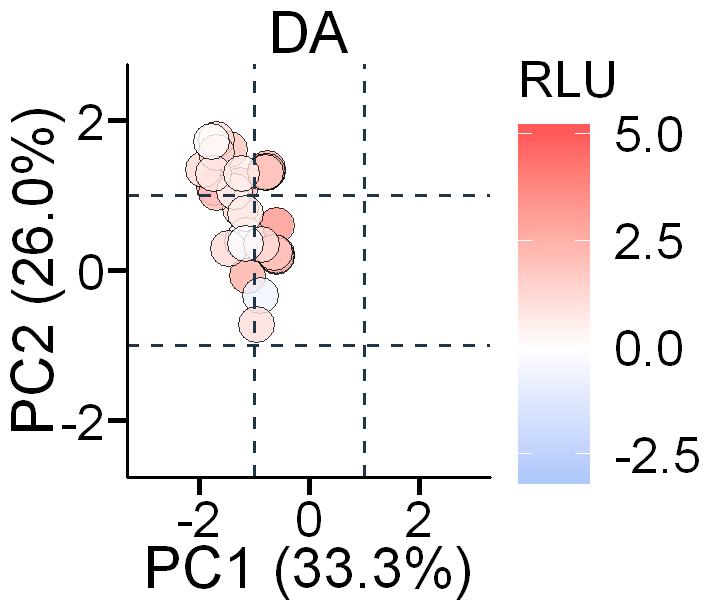

In [109]:
#Plot DA

# Generate the plot
hist_data <- subset(pca_data, Opt_Method == 'DA')
rlu_mid = 0
rlu_min = -3
rlu_max = 5

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#72a5f8", mid = "#ffffff", high = "#ff5959", midpoint = rlu_mid, limits = c(rlu_min, rlu_max)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "DA",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 30), # Increase the size of the legend title
        )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_DA.png")
ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)



Warning message:
"Removed 3 rows containing missing values (geom_point)."Warning message:
"Removed 3 rows containing missing values (geom_point)."

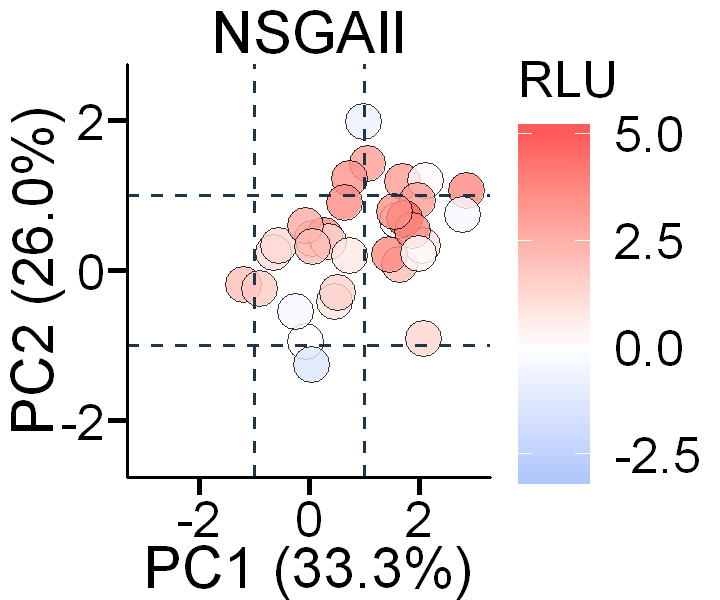

In [111]:
#Plot NSGAII

# Generate the plot
hist_data <- subset(pca_data, Opt_Method == 'NSGAII')
rlu_mid = 0
rlu_min = -3
rlu_max = 5

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#72a5f8", mid = "#ffffff", high = "#ff5959", midpoint = rlu_mid, limits = c(rlu_min, rlu_max)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "NSGAII",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 30), # Increase the size of the legend title
        )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_NSGAII.png")
ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)

